# Machine Learning Pipeline: Feature Importance Analysis

This notebook analyzes the `data.xlsx` dataset to find the most associated factors (features) that contribute to a specific target variable (e.g., Mental Exhaustion, Stress, or Academic Satisfaction).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.filterwarnings('ignore')

In [2]:
# 1. Load the dataset
df = pd.read_excel('data.xlsx')
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (10, 39)


,লিঙ্গ,বয়স,আবাসন,মাসিক পারিবারিক আয় (টাকা),উচ্চতা (ফিট),ওজন (কে.জি),অনুষদ (Faculty),অধ্যয়নের বর্ষ,বর্তমান গড় সিজিপিএ (৪.০০ এর মধ্যে),কোর্সের পাঠ্যক্রম এবং অ্যাসাইনমেন্টের বিশাল চাপে আমি হিমশিম খাই।,...,বিশ্ববিদ্যালয়ে ভর্তি হওয়ার পর থেকে আমি আমার পড়াশোনার আগ্রহ হারিয়ে ফেলেছি।,আমি আমার পড়াশোনার প্রতি নিরুৎসাহী হয়ে পড়েছি।,আমি আমার পড়াশোনার সম্ভাব্য উপকারিতা সম্পর্কে আরও বেশি নিরাশ হয়ে পড়ছি।,আমি আমার পড়াশোনার গুরুত্ব নিয়ে সন্দিহান।,আমার পড়াশোনার মধ্যে যে সমস্যাগুলো দেখা দেয় তা আমি কার্যকরভাবে সমাধান করতে পারি।,আমি বিশ্বাস করি আমি যে ক্লাসগুলোতে যোগদান করি তাতে আমি কার্যকর ভূমিকা রাখি।,"আমার মতে, আমি একজন ভালো ছাত্র/ছাত্রী।",আমি যখন আমার পড়াশোনার লক্ষ্য অর্জন করি তখন আমি অনুপ্রাণিত বোধ করি।,আমি আমার অধ্যয়ন কালে অনেক গুরুত্বপূর্ণ বিষয় শিখেছি।,ক্লাস চলাকালীন সময়ে সার্থকভাবে কাজগুলো সম্পন্ন করতে আমি আত্মবিশ্বাসী বোধ করি।
0,পুরুষ,24,বিশ্ববিদ্যালয় হল,40000,5.6,51,Science,৪র্থ বর্ষ,3.690,একমত,...,একমত,কিছুটা একমত,একমত,নিরপেক্ষ,নিরপেক্ষ,কিছুটা ভিন্নমত,ভিন্নমত,কিছুটা একমত,নিরপেক্ষ,কিছুটা ভিন্নমত
1,পুরুষ,23,বিশ্ববিদ্যালয় হল,30K,"5'5""",58,Science,মাস্টার্স,3.810,ভিন্নমত,...,ভিন্নমত,সম্পূর্ণ ভিন্নমত,সম্পূর্ণ ভিন্নমত,সম্পূর্ণ ভিন্নমত,একমত,একমত,একমত,একমত,একমত,একমত
2,পুরুষ,23,মেস/হোস্টেল,30000,5.8,58,science,৪র্থ বর্ষ,3.240,একমত,...,সম্পূর্ণ একমত,সম্পূর্ণ একমত,সম্পূর্ণ একমত,সম্পূর্ণ একমত,ভিন্নমত,সম্পূর্ণ ভিন্নমত,ভিন্নমত,একমত,নিরপেক্ষ,ভিন্নমত
3,মহিলা,23,মেস/হোস্টেল,50000,"5'3""",60,Science,৩য় বর্ষ,3.120,নিরপেক্ষ,...,সম্পূর্ণ একমত,সম্পূর্ণ একমত,সম্পূর্ণ একমত,সম্পূর্ণ একমত,কিছুটা একমত,কিছুটা একমত,একমত,একমত,কিছুটা একমত,একমত
4,পুরুষ,22,মেস/হোস্টেল,২০ হাজার,5.6,60,Science,২য় বর্ষ,3.567,ভিন্নমত,...,কিছুটা একমত,নিরপেক্ষ,নিরপেক্ষ,নিরপেক্ষ,একমত,নিরপেক্ষ,কিছুটা একমত,একমত,একমত,একমত


## Preprocessing
Most of the data is categorical (e.g., Likert scale responses). We will use `LabelEncoder` to convert these text values into numerical values so that the ML models can process them.

In [3]:
# Handle missing values by filling them with a placeholder
df = df.fillna('Missing')

# Encode categorical variables
label_encoders = {}
df_encoded = df.copy()

for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
        label_encoders[col] = le

df_encoded.head()

,লিঙ্গ,বয়স,আবাসন,মাসিক পারিবারিক আয় (টাকা),উচ্চতা (ফিট),ওজন (কে.জি),অনুষদ (Faculty),অধ্যয়নের বর্ষ,বর্তমান গড় সিজিপিএ (৪.০০ এর মধ্যে),কোর্সের পাঠ্যক্রম এবং অ্যাসাইনমেন্টের বিশাল চাপে আমি হিমশিম খাই।,...,বিশ্ববিদ্যালয়ে ভর্তি হওয়ার পর থেকে আমি আমার পড়াশোনার আগ্রহ হারিয়ে ফেলেছি।,আমি আমার পড়াশোনার প্রতি নিরুৎসাহী হয়ে পড়েছি।,আমি আমার পড়াশোনার সম্ভাব্য উপকারিতা সম্পর্কে আরও বেশি নিরাশ হয়ে পড়ছি।,আমি আমার পড়াশোনার গুরুত্ব নিয়ে সন্দিহান।,আমার পড়াশোনার মধ্যে যে সমস্যাগুলো দেখা দেয় তা আমি কার্যকরভাবে সমাধান করতে পারি।,আমি বিশ্বাস করি আমি যে ক্লাসগুলোতে যোগদান করি তাতে আমি কার্যকর ভূমিকা রাখি।,"আমার মতে, আমি একজন ভালো ছাত্র/ছাত্রী।",আমি যখন আমার পড়াশোনার লক্ষ্য অর্জন করি তখন আমি অনুপ্রাণিত বোধ করি।,আমি আমার অধ্যয়ন কালে অনেক গুরুত্বপূর্ণ বিষয় শিখেছি।,ক্লাস চলাকালীন সময়ে সার্থকভাবে কাজগুলো সম্পন্ন করতে আমি আত্মবিশ্বাসী বোধ করি।
0,0,24,0,4,5,51,1,3,3.690,0,...,0,1,0,2,3,2,4,1,3,2
1,0,23,0,3,4,58,1,0,3.810,2,...,3,5,4,4,0,0,0,0,0,0
2,0,23,1,2,7,58,2,3,3.240,0,...,4,4,3,3,4,5,4,0,3,3
3,1,23,1,5,3,60,1,2,3.120,1,...,4,4,3,3,1,1,0,0,1,0
4,0,22,1,8,5,60,0,1,3.567,2,...,1,3,2,2,0,3,1,0,0,0


## Select Target Variable
We need to choose a target variable to predict. Let's use **'আমি আমার পড়াশোনার কারনে মানসিকভাবে ক্লান্ত বোধ করি'** (I feel mentally exhausted because of my studies) as an example target. 

*You can change `target_col` to any other column you want to analyze.*

In [4]:
# Define the target column (Update this to your preferred target variable)
target_col = 'আমি আমার পড়াশোনার কারনে মানসিকভাবে ক্লান্ত বোধ করি'

if target_col not in df.columns:
    # Fallback if the column is not found (pick a valid column)
    target_col = df.columns[-5]

print(f"Target Variable: {target_col}")

X = df_encoded.drop(columns=[target_col])
y = df_encoded[target_col]

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Target Variable: আমি আমার পড়াশোনার কারনে মানসিকভাবে ক্লান্ত বোধ করি


## Model 1: Random Forest Feature Importance
Random Forest provides a natural way to calculate the importance of each feature based on how much it decreases impurity across all trees in the forest.

In [5]:
# Train a Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Get feature importances
importances = rf_model.feature_importances_
feature_names = X.columns

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("Top 10 Most Associated Factors (Random Forest):")
display(feature_importance_df.head(10))

Top 10 Most Associated Factors (Random Forest):


,Feature,Importance
1,বয়স,0.205288
23,বিশ্ববিদ্যালয় ক্যাম্পাসের শারীরিক ও সামাজিক পর...,0.073730
29,আমি আমার পড়াশোনার প্রতি নিরুৎসাহী হয়ে পড়েছি।,0.065996
8,বর্তমান গড় সিজিপিএ (৪.০০ এর মধ্যে),0.062219
22,বাবা-মায়ের উচ্চ প্রত্যাশা পূরণ করা আমার জন্য এ...,0.059681
37,ক্লাস চলাকালীন সময়ে সার্থকভাবে কাজগুলো সম্পন্...,0.045000
11,ডিজিটাল বা অনলাইন লার্নিং টুলস ব্যবহার করা আমা...,0.042516
33,আমি বিশ্বাস করি আমি যে ক্লাসগুলোতে যোগদান করি ...,0.037200
30,আমি আমার পড়াশোনার সম্ভাব্য উপকারিতা সম্পর্কে ...,0.036713
4,উচ্চতা (ফিট),0.031676


## Model 2: Correlation Analysis
We can also look at the absolute Pearson correlation between the features and the target variable. This is a simpler linear approach.

In [6]:
correlations = df_encoded.corr()[target_col].drop(target_col)
corr_df = pd.DataFrame({
    'Feature': correlations.index,
    'Correlation': correlations.values,
    'Abs_Correlation': np.abs(correlations.values)
}).sort_values(by='Abs_Correlation', ascending=False)

print("Top 10 Most Associated Factors (Correlation):")
display(corr_df.head(10))

Top 10 Most Associated Factors (Correlation):


,Feature,Correlation,Abs_Correlation
4,উচ্চতা (ফিট),0.581779,0.581779
1,বয়স,-0.522423,0.522423
21,সহপাঠীদের সাথে আমার ভালো সম্পর্ক আছে এবং পড়াশো...,-0.488149,0.488149
29,আমি আমার পড়াশোনার প্রতি নিরুৎসাহী হয়ে পড়েছি।,0.469967,0.469967
33,আমি বিশ্বাস করি আমি যে ক্লাসগুলোতে যোগদান করি ...,0.421272,0.421272
22,বাবা-মায়ের উচ্চ প্রত্যাশা পূরণ করা আমার জন্য এ...,-0.397663,0.397663
24,দিন শেষে বিশ্ববিদ্যালয়ে আমি পুরোপুরি বিধ্বস্ত...,0.381849,0.381849
25,আমি যখন সকালে উঠি এবং আমাকে বিশ্ববিদ্যালয়ে আর...,0.352437,0.352437
35,আমি যখন আমার পড়াশোনার লক্ষ্য অর্জন করি তখন আম...,-0.344782,0.344782
3,মাসিক পারিবারিক আয় (টাকা),0.324010,0.324010


## Visualization
Visualizing the top features from the Random Forest model.

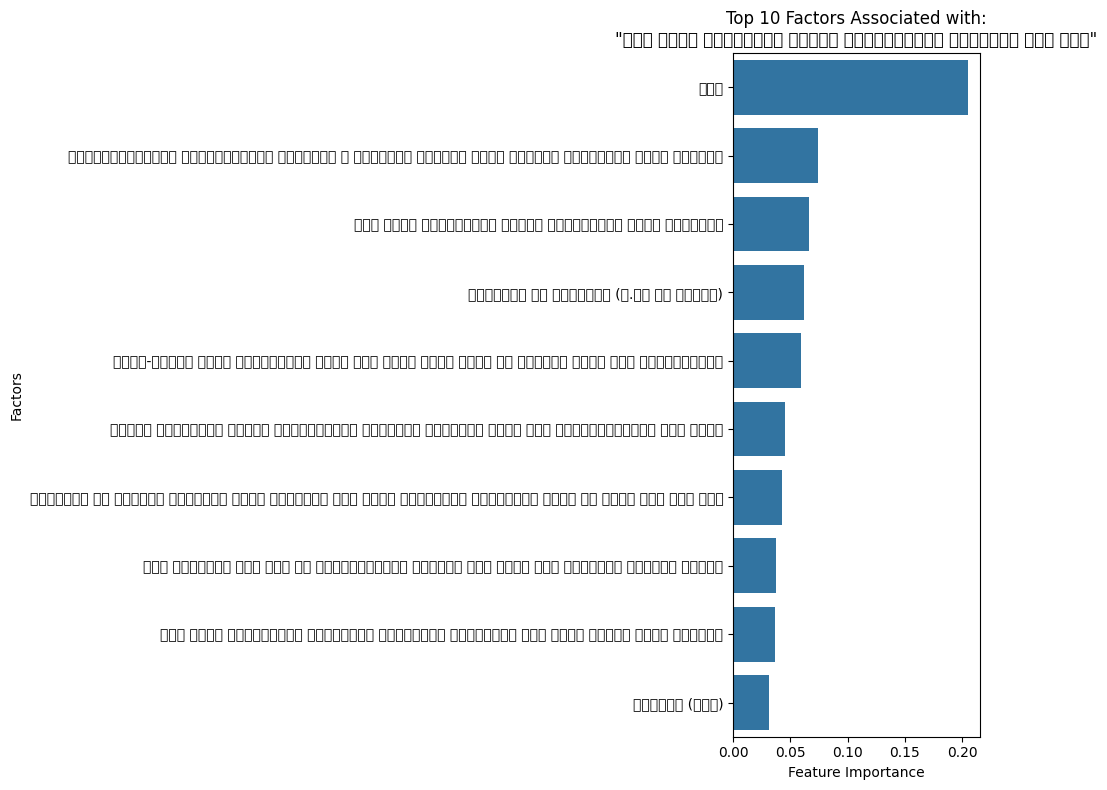

In [7]:
# Plot the top 10 features
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10))
plt.title(f'Top 10 Factors Associated with:\n"{target_col}"')
plt.xlabel('Feature Importance')
plt.ylabel('Factors')

# Note: Bengali fonts might appear as squares depending on OS/Jupyter config. 
# You may need to set a specific font family if that happens.
# plt.rcParams['font.family'] = 'Kalpurush' 

plt.tight_layout()
plt.show()